# Final Model Evaluation

This notebook compares all stock-prediction experiments on a
common test period.

## Models

1. Naive persistence baseline
2. Direct-Price LSTM
3. Log-Return LSTM
4. Log-Return GRU

## Evaluation Criteria

- MAE
- MSE
- RMSE
- Improvement over the naive baseline
- Direction accuracy
- Training time
- Number of trainable parameters
- Prediction behavior over time

To ensure a fair comparison, all price-based metrics are calculated
again using only dates shared by all experiments.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)


## Load Experiment Results

In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

results_directory = project_root / "results"


In [3]:
direct_lstm_df = pd.read_csv(
    results_directory / "lstm_predictions.csv",
    parse_dates=["date"],
)

log_lstm_df = pd.read_csv(
    results_directory / "lstm_log_return_predictions.csv",
    parse_dates=["date"],
)

gru_df = pd.read_csv(
    results_directory / "gru_log_return_predictions.csv",
    parse_dates=["date"],
)

for dataframe in (
    direct_lstm_df,
    log_lstm_df,
    gru_df,
):
    dataframe["date"] = (
        pd.to_datetime(
            dataframe["date"],
            utc=True,
        )
        .dt.tz_convert(None)
        .dt.normalize()
    )


In [4]:
print("Direct LSTM:")
print(direct_lstm_df.columns.tolist())

print("\nLog-Return LSTM:")
print(log_lstm_df.columns.tolist())

print("\nLog-Return GRU:")
print(gru_df.columns.tolist())


Direct LSTM:
['date', 'actual', 'baseline', 'lstm', 'lstm_error', 'lstm_absolute_error']

Log-Return LSTM:
['date', 'previous_price', 'actual_price', 'actual_return', 'predicted_return', 'baseline_price', 'predicted_price']

Log-Return GRU:
['date', 'previous_price', 'actual_price', 'actual_return', 'predicted_return', 'baseline_price', 'gru_price', 'absolute_error']


In [5]:
for name, dataframe in {
    "Direct LSTM": direct_lstm_df,
    "Log-Return LSTM": log_lstm_df,
    "Log-Return GRU": gru_df,
}.items():
    print(
        name,
        "|",
        dataframe["date"].min(),
        "→",
        dataframe["date"].max(),
        "| Samples:",
        len(dataframe),
    )


Direct LSTM | 2024-05-07 00:00:00 → 2025-12-31 00:00:00 | Samples: 415
Log-Return LSTM | 2024-05-07 00:00:00 → 2025-12-31 00:00:00 | Samples: 415
Log-Return GRU | 2024-05-07 00:00:00 → 2025-12-31 00:00:00 | Samples: 415


## Common Test Period

In [6]:
direct_comparison = direct_lstm_df[
    [
        "date",
        "actual",
        "baseline",
        "lstm",
    ]
].rename(
    columns={
        "actual": "direct_actual",
        "baseline": "direct_baseline",
        "lstm": "direct_lstm",
    }
)

log_lstm_comparison = log_lstm_df[
    [
        "date",
        "previous_price",
        "actual_price",
        "actual_return",
        "predicted_return",
        "baseline_price",
        "predicted_price",
    ]
].rename(
    columns={
        "predicted_return":
            "lstm_predicted_return",
        "baseline_price":
            "log_baseline",
        "predicted_price":
            "log_return_lstm",
    }
)

gru_comparison = gru_df[
    [
        "date",
        "actual_price",
        "actual_return",
        "predicted_return",
        "baseline_price",
        "gru_price",
    ]
].rename(
    columns={
        "actual_price":
            "gru_actual",
        "actual_return":
            "gru_actual_return",
        "predicted_return":
            "gru_predicted_return",
        "baseline_price":
            "gru_baseline",
        "gru_price":
            "log_return_gru",
    }
)


In [7]:
comparison_df = (
    direct_comparison
    .merge(
        log_lstm_comparison,
        on="date",
        how="inner",
    )
    .merge(
        gru_comparison,
        on="date",
        how="inner",
    )
)

comparison_df = (
    comparison_df
    .sort_values("date")
    .reset_index(drop=True)
)

print(
    "Common test period:",
    comparison_df["date"].min(),
    "→",
    comparison_df["date"].max(),
)

print(
    "Common test samples:",
    len(comparison_df),
)


Common test period: 2024-05-07 00:00:00 → 2025-12-31 00:00:00
Common test samples: 415


In [8]:
if not np.allclose(
    comparison_df["direct_actual"],
    comparison_df["actual_price"],
):
    raise ValueError(
        "Direct LSTM and log-return experiments "
        "have different actual prices."
    )

if not np.allclose(
    comparison_df["actual_price"],
    comparison_df["gru_actual"],
):
    raise ValueError(
        "LSTM and GRU actual prices do not match."
    )

if not np.allclose(
    comparison_df["log_baseline"],
    comparison_df["gru_baseline"],
):
    raise ValueError(
        "LSTM and GRU baselines do not match."
    )


In [9]:
evaluation_df = pd.DataFrame({
    "date":
        comparison_df["date"],
    "previous_price":
        comparison_df["previous_price"],
    "actual_price":
        comparison_df["actual_price"],
    "naive_baseline":
        comparison_df["log_baseline"],
    "direct_lstm":
        comparison_df["direct_lstm"],
    "log_return_lstm":
        comparison_df["log_return_lstm"],
    "log_return_gru":
        comparison_df["log_return_gru"],
    "actual_return":
        comparison_df["actual_return"],
    "lstm_predicted_return":
        comparison_df[
            "lstm_predicted_return"
        ],
    "gru_predicted_return":
        comparison_df[
            "gru_predicted_return"
        ],
})

evaluation_df.head()


,date,previous_price,actual_price,naive_baseline,direct_lstm,log_return_lstm,log_return_gru,actual_return,lstm_predicted_return,gru_predicted_return
0,2024-05-07,179.750443,180.432968,179.750443,171.65572,179.805812,179.720883,0.003790,0.000308,-0.000164
1,2024-05-08,180.432968,180.769318,180.432968,172.80301,180.520425,180.427569,0.001862,0.000485,-0.000030
2,2024-05-09,180.769318,182.579605,180.769318,173.84523,180.891761,180.802999,0.009965,0.000677,0.000186
3,2024-05-10,182.579605,181.321564,182.579605,174.83226,182.726847,182.639612,-0.006914,0.000806,0.000329
4,2024-05-13,181.321564,184.521072,181.321564,175.62756,181.449180,181.396331,0.017492,0.000704,0.000412


## Price Metrics

In [10]:
def calculate_regression_metrics(
    actual: np.ndarray,
    predicted: np.ndarray,
) -> dict:
    mae = mean_absolute_error(
        actual,
        predicted,
    )

    mse = mean_squared_error(
        actual,
        predicted,
    )

    rmse = np.sqrt(mse)

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
    }


In [11]:
actual_prices = evaluation_df[
    "actual_price"
].to_numpy()

prediction_columns = {
    "Naive Baseline":
        "naive_baseline",
    "Direct-Price LSTM":
        "direct_lstm",
    "Log-Return LSTM":
        "log_return_lstm",
    "Log-Return GRU":
        "log_return_gru",
}

metric_rows = []

for model_name, column_name in (
    prediction_columns.items()
):
    predictions = evaluation_df[
        column_name
    ].to_numpy()

    metrics = calculate_regression_metrics(
        actual_prices,
        predictions,
    )

    metric_rows.append({
        "model": model_name,
        **metrics,
    })

metrics_df = pd.DataFrame(
    metric_rows
)

metrics_df.round(4)


,model,mae,mse,rmse
0,Naive Baseline,2.5887,14.7321,3.8382
1,Direct-Price LSTM,36.3403,1713.5225,41.3947
2,Log-Return LSTM,2.5820,14.6314,3.8251
3,Log-Return GRU,2.5919,14.7714,3.8434


In [12]:
baseline_rmse = metrics_df.loc[
    metrics_df["model"]
    == "Naive Baseline",
    "rmse",
].iloc[0]

metrics_df[
    "rmse_improvement_vs_baseline_pct"
] = (
    (
        baseline_rmse
        - metrics_df["rmse"]
    )
    / baseline_rmse
    * 100
)

metrics_df.round(4)


,model,mae,mse,rmse,rmse_improvement_vs_baseline_pct
0,Naive Baseline,2.5887,14.7321,3.8382,0.0000
1,Direct-Price LSTM,36.3403,1713.5225,41.3947,-978.4827
2,Log-Return LSTM,2.5820,14.6314,3.8251,0.3423
3,Log-Return GRU,2.5919,14.7714,3.8434,-0.1333


## Direction Accuracy

In [13]:
def calculate_direction_accuracy(
    previous_prices: np.ndarray,
    actual_prices: np.ndarray,
    predicted_prices: np.ndarray,
) -> float:
    actual_direction = np.sign(
        actual_prices
        - previous_prices
    )

    predicted_direction = np.sign(
        predicted_prices
        - previous_prices
    )

    accuracy = np.mean(
        actual_direction
        == predicted_direction
    )

    return accuracy * 100


In [14]:
previous_prices = evaluation_df[
    "previous_price"
].to_numpy()

direction_rows = []

for model_name, column_name in {
    "Direct-Price LSTM":
        "direct_lstm",
    "Log-Return LSTM":
        "log_return_lstm",
    "Log-Return GRU":
        "log_return_gru",
}.items():
    predicted_prices = evaluation_df[
        column_name
    ].to_numpy()

    accuracy = calculate_direction_accuracy(
        previous_prices,
        actual_prices,
        predicted_prices,
    )

    direction_rows.append({
        "model": model_name,
        "direction_accuracy_pct":
            accuracy,
    })

direction_df = pd.DataFrame(
    direction_rows
)

direction_df.round(2)


,model,direction_accuracy_pct
0,Direct-Price LSTM,42.41
1,Log-Return LSTM,53.98
2,Log-Return GRU,52.77


In [15]:
metrics_df = metrics_df.merge(
    direction_df,
    on="model",
    how="left",
)

metrics_df.round(4)


,model,mae,mse,rmse,rmse_improvement_vs_baseline_pct,direction_accuracy_pct
0,Naive Baseline,2.5887,14.7321,3.8382,0.0000,NaN
1,Direct-Price LSTM,36.3403,1713.5225,41.3947,-978.4827,42.4096
2,Log-Return LSTM,2.5820,14.6314,3.8251,0.3423,53.9759
3,Log-Return GRU,2.5919,14.7714,3.8434,-0.1333,52.7711


## Training Metadata

In [16]:
direct_metadata = pd.read_csv(
    results_directory / "lstm_metrics.csv"
)

lstm_metadata = pd.read_csv(
    results_directory
    / "lstm_log_return_metrics.csv"
)

gru_metadata = pd.read_csv(
    results_directory
    / "gru_log_return_metrics.csv"
)

display(direct_metadata)
display(lstm_metadata)
display(gru_metadata)


,model,mae,mse,rmse,training_time_seconds
0,LSTM,36.340309,1713.522583,41.394717,7.087083


,model,mae,mse,rmse,return_rmse,direction_accuracy_pct,training_time_seconds
0,Log-Return LSTM,2.581986,14.631363,3.825097,0.017859,53.975904,9.163661


,model,mae,mse,rmse,return_rmse,direction_accuracy_pct,training_time_seconds,parameters
0,Log-Return GRU,2.591856,14.77136,3.843353,0.017959,52.771084,30.818724,9729


In [17]:
def get_metric_value(
    dataframe: pd.DataFrame,
    column: str,
) -> float:
    if column not in dataframe.columns:
        return np.nan

    return dataframe[column].iloc[0]


In [18]:
metadata_df = pd.DataFrame({
    "model": [
        "Direct-Price LSTM",
        "Log-Return LSTM",
        "Log-Return GRU",
    ],
    "training_time_seconds": [
        get_metric_value(
            direct_metadata,
            "training_time_seconds",
        ),
        get_metric_value(
            lstm_metadata,
            "training_time_seconds",
        ),
        get_metric_value(
            gru_metadata,
            "training_time_seconds",
        ),
    ],
    "parameters": [
        get_metric_value(
            direct_metadata,
            "parameters",
        ),
        get_metric_value(
            lstm_metadata,
            "parameters",
        ),
        get_metric_value(
            gru_metadata,
            "parameters",
        ),
    ],
})

metadata_df


,model,training_time_seconds,parameters
0,Direct-Price LSTM,7.087083,NaN
1,Log-Return LSTM,9.163661,NaN
2,Log-Return GRU,30.818724,9729.0


In [19]:
final_metrics_df = metrics_df.merge(
    metadata_df,
    on="model",
    how="left",
)

final_metrics_df.round(4)


,model,mae,mse,rmse,rmse_improvement_vs_baseline_pct,direction_accuracy_pct,training_time_seconds,parameters
0,Naive Baseline,2.5887,14.7321,3.8382,0.0000,NaN,NaN,NaN
1,Direct-Price LSTM,36.3403,1713.5225,41.3947,-978.4827,42.4096,7.0871,NaN
2,Log-Return LSTM,2.5820,14.6314,3.8251,0.3423,53.9759,9.1637,NaN
3,Log-Return GRU,2.5919,14.7714,3.8434,-0.1333,52.7711,30.8187,9729.0


In [20]:
best_rmse_row = final_metrics_df.loc[
    final_metrics_df["rmse"].idxmin()
]

print(
    "Lowest RMSE:",
    best_rmse_row["model"],
    "→",
    round(
        best_rmse_row["rmse"],
        4,
    ),
)

neural_models_df = final_metrics_df[
    final_metrics_df["model"]
    != "Naive Baseline"
]

best_neural_model = neural_models_df.loc[
    neural_models_df["rmse"].idxmin()
]

print(
    "Best neural model:",
    best_neural_model["model"],
)

print(
    "RMSE:",
    round(
        best_neural_model["rmse"],
        4,
    ),
)


Lowest RMSE: Log-Return LSTM → 3.8251
Best neural model: Log-Return LSTM
RMSE: 3.8251


## Visual Comparison

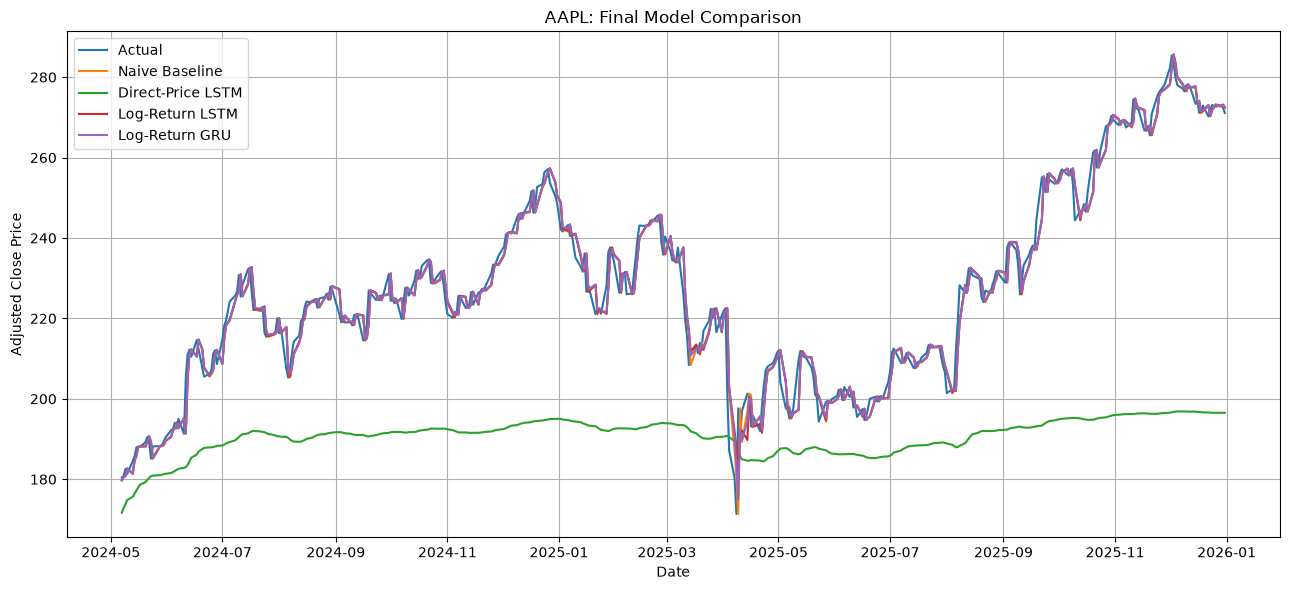

In [21]:
plt.figure(figsize=(13, 6))

plt.plot(
    evaluation_df["date"],
    evaluation_df["actual_price"],
    label="Actual",
)

plt.plot(
    evaluation_df["date"],
    evaluation_df["naive_baseline"],
    label="Naive Baseline",
)

plt.plot(
    evaluation_df["date"],
    evaluation_df["direct_lstm"],
    label="Direct-Price LSTM",
)

plt.plot(
    evaluation_df["date"],
    evaluation_df["log_return_lstm"],
    label="Log-Return LSTM",
)

plt.plot(
    evaluation_df["date"],
    evaluation_df["log_return_gru"],
    label="Log-Return GRU",
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.title(
    "AAPL: Final Model Comparison"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

comparison_plot_path = (
    results_directory
    / "final_model_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=150,
)

plt.show()


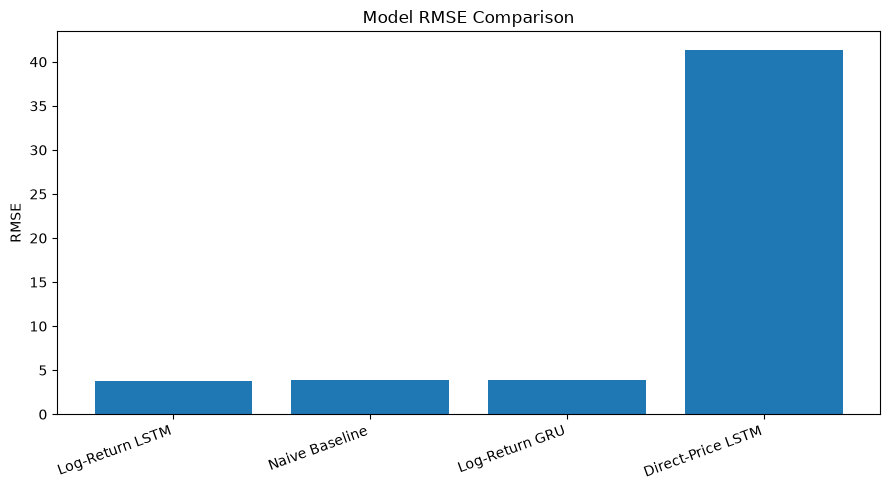

In [22]:
plot_metrics_df = (
    final_metrics_df
    .sort_values("rmse")
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_metrics_df["model"],
    plot_metrics_df["rmse"],
)

plt.ylabel("RMSE")
plt.title(
    "Model RMSE Comparison"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

rmse_plot_path = (
    results_directory
    / "rmse_comparison.png"
)

plt.savefig(
    rmse_plot_path,
    dpi=150,
)

plt.show()


In [23]:
evaluation_df[
    "baseline_absolute_error"
] = (
    evaluation_df["actual_price"]
    - evaluation_df["naive_baseline"]
).abs()

evaluation_df[
    "direct_lstm_absolute_error"
] = (
    evaluation_df["actual_price"]
    - evaluation_df["direct_lstm"]
).abs()

evaluation_df[
    "log_lstm_absolute_error"
] = (
    evaluation_df["actual_price"]
    - evaluation_df["log_return_lstm"]
).abs()

evaluation_df[
    "gru_absolute_error"
] = (
    evaluation_df["actual_price"]
    - evaluation_df["log_return_gru"]
).abs()


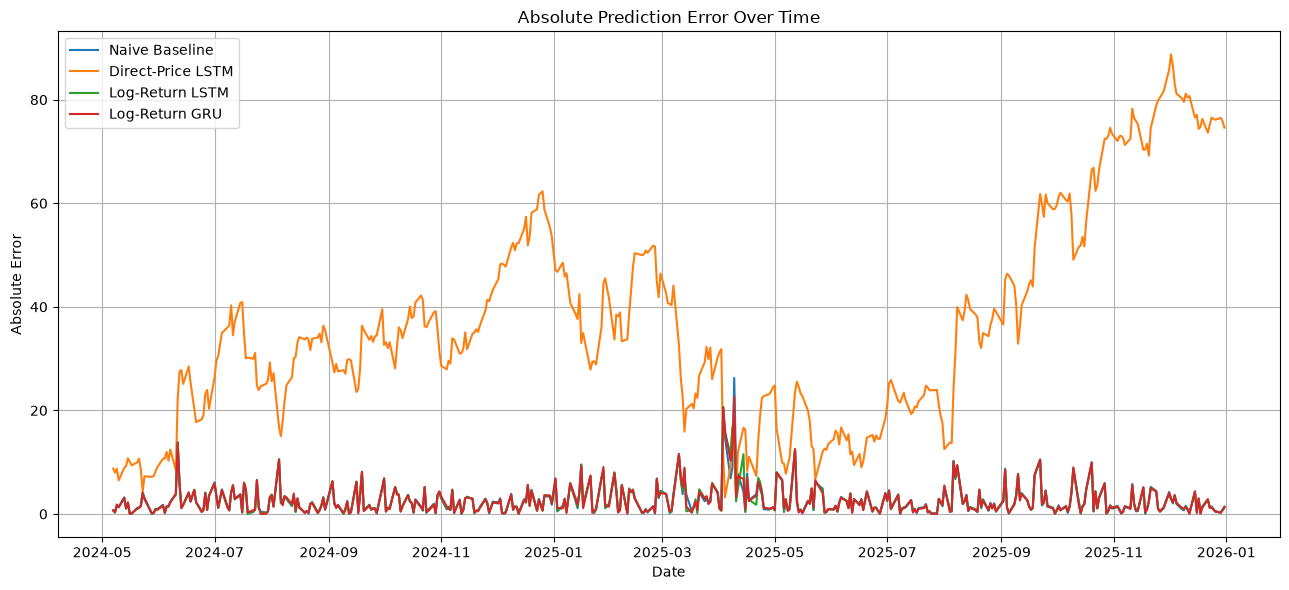

In [24]:
plt.figure(figsize=(13, 6))

plt.plot(
    evaluation_df["date"],
    evaluation_df[
        "baseline_absolute_error"
    ],
    label="Naive Baseline",
)

plt.plot(
    evaluation_df["date"],
    evaluation_df[
        "direct_lstm_absolute_error"
    ],
    label="Direct-Price LSTM",
)

plt.plot(
    evaluation_df["date"],
    evaluation_df[
        "log_lstm_absolute_error"
    ],
    label="Log-Return LSTM",
)

plt.plot(
    evaluation_df["date"],
    evaluation_df[
        "gru_absolute_error"
    ],
    label="Log-Return GRU",
)

plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.title(
    "Absolute Prediction Error Over Time"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

error_plot_path = (
    results_directory
    / "absolute_error_comparison.png"
)

plt.savefig(
    error_plot_path,
    dpi=150,
)

plt.show()


## Error Analysis

In [25]:
worst_gru_predictions = (
    evaluation_df[
        [
            "date",
            "previous_price",
            "actual_price",
            "log_return_gru",
            "gru_absolute_error",
        ]
    ]
    .sort_values(
        "gru_absolute_error",
        ascending=False,
    )
    .head(10)
)

worst_gru_predictions.round(4)


/var/folders/90/d56h_t5s7gbb06rb5htlt0300000gn/T/ipykernel_51621/3757016723.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  worst_gru_predictions.round(4)


,date,previous_price,actual_price,log_return_gru,gru_absolute_error
231,2025-04-09,171.3660,197.6344,175.0260,22.6084
227,2025-04-03,222.5213,201.9478,222.5503,20.6025
228,2025-04-04,201.9478,187.2284,203.3124,16.0840
24,2024-06-11,191.2965,205.1940,191.4530,13.7410
230,2025-04-08,180.3507,171.3660,183.9284,12.5624
253,2025-05-12,197.3163,209.7761,197.3129,12.4632
209,2025-03-10,237.6085,226.0894,237.5961,11.5067
61,2024-08-05,217.7840,207.2940,217.8000,10.5060
344,2025-09-22,244.5965,255.1375,244.6667,10.4708
229,2025-04-07,187.2284,180.3507,190.6365,10.2858


In [26]:
worst_lstm_predictions = (
    evaluation_df[
        [
            "date",
            "previous_price",
            "actual_price",
            "log_return_lstm",
            "log_lstm_absolute_error",
        ]
    ]
    .sort_values(
        "log_lstm_absolute_error",
        ascending=False,
    )
    .head(10)
)

worst_lstm_predictions.round(4)


/var/folders/90/d56h_t5s7gbb06rb5htlt0300000gn/T/ipykernel_51621/1735632751.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  worst_lstm_predictions.round(4)


,date,previous_price,actual_price,log_return_lstm,log_lstm_absolute_error
227,2025-04-03,222.5213,201.9478,222.6241,20.6763
231,2025-04-09,171.3660,197.6344,179.5697,18.0647
230,2025-04-08,180.3507,171.3660,187.8976,16.5317
228,2025-04-04,201.9478,187.2284,202.6166,15.3882
24,2024-06-11,191.2965,205.1940,191.3957,13.7983
253,2025-05-12,197.3163,209.7761,197.2495,12.5266
229,2025-04-07,187.2284,180.3507,191.9684,11.6177
209,2025-03-10,237.6085,226.0894,237.7018,11.6125
234,2025-04-14,196.9387,201.2820,189.7464,11.5356
61,2024-08-05,217.7840,207.2940,217.8854,10.5914


In [27]:
direct_rmse = final_metrics_df.loc[
    final_metrics_df["model"]
    == "Direct-Price LSTM",
    "rmse",
].iloc[0]

log_lstm_rmse = final_metrics_df.loc[
    final_metrics_df["model"]
    == "Log-Return LSTM",
    "rmse",
].iloc[0]

representation_improvement = (
    (
        direct_rmse
        - log_lstm_rmse
    )
    / direct_rmse
    * 100
)

print(
    "RMSE improvement after changing "
    "price-level prediction to "
    "log-return prediction:"
)

print(
    f"{representation_improvement:.2f}%"
)


RMSE improvement after changing price-level prediction to log-return prediction:
90.76%


## Save Final Results

In [28]:
final_metrics_path = (
    results_directory
    / "final_model_metrics.csv"
)

final_metrics_df.to_csv(
    final_metrics_path,
    index=False,
)

evaluation_path = (
    results_directory
    / "final_predictions.csv"
)

evaluation_df.to_csv(
    evaluation_path,
    index=False,
)

print("Saved:", final_metrics_path)
print("Saved:", evaluation_path)
print("Saved:", comparison_plot_path)
print("Saved:", rmse_plot_path)
print("Saved:", error_plot_path)


Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/final_model_metrics.csv
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/final_predictions.csv
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/final_model_comparison.png
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/rmse_comparison.png
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/absolute_error_comparison.png


## Evaluation Summary

Four forecasting approaches were evaluated on the same common test
period:

1. Naive persistence baseline
2. Direct-Price LSTM
3. Log-Return LSTM
4. Log-Return GRU

All MAE, MSE and RMSE values in this notebook were recalculated on
the same dates to ensure a fair comparison.

The original Direct-Price LSTM experiment demonstrated that low
training and validation errors did not guarantee generalization to
future price regimes.

The log-return experiments were introduced to reduce the models'
dependence on absolute stock-price levels.

The final interpretation of the experiment will consider:

- whether either neural network outperformed the naive baseline,
- whether log-return modeling improved upon direct price prediction,
- whether LSTM or GRU performed better,
- directional prediction accuracy,
- model complexity,
- and training time.

The numerical findings and final conclusions will be added after
reviewing the comparison results.
